<a href="https://colab.research.google.com/github/jyryu3161/LAIDD_metabolicmodeling/blob/main/lec03_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q --upgrade "cobra>=0.31.1" hopsy swiglpk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.5 MB/s eta 0:00:00


# Loading a model and inspecting it

In [ ]:
import cobra
from cobra.io import load_model

# "iJO1366" and "salmonella" are also valid arguments
model = load_model("textbook")

In [ ]:
model

Name,e_coli_core
Memory address,7d2201fd75f0
Number of metabolites,72
Number of reactions,95
Number of genes,137
Number of groups,0
Objective expression,1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
Compartments,"cytosol, extracellular"


In [ ]:
print(len(model.reactions))
print(len(model.metabolites))
print(len(model.genes))

95
72
137


## Running pFBA

In [ ]:
model.objective = 'Biomass_Ecoli_core'
fba_solution = model.optimize()
pfba_solution = cobra.flux_analysis.pfba(model)

# Simulating Deletions

In [ ]:
import pandas
from time import time

from cobra.io import load_model
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)

cobra_model = load_model("textbook")
ecoli_model = load_model("iJO1366")



## Knocking out single genes and reactions

In [ ]:
print('complete model: ', cobra_model.optimize())
with cobra_model:
    cobra_model.reactions.PFK.knock_out()
    print('pfk knocked out: ', cobra_model.optimize())




complete model:  <Solution 0.874 at 0x7d21ccf61eb0>
pfk knocked out:  <Solution 0.704 at 0x7d21ccf60c80>


In [ ]:
print('complete model: ', cobra_model.optimize())
with cobra_model:
    cobra_model.genes.b1723.knock_out()
    print('pfkA knocked out: ', cobra_model.optimize())
    cobra_model.genes.b3916.knock_out()
    print('pfkB knocked out: ', cobra_model.optimize())



complete model:  <Solution 0.874 at 0x7d21ccf63920>
pfkA knocked out:  <Solution 0.874 at 0x7d21ccf614c0>
pfkB knocked out:  <Solution 0.704 at 0x7d21ccf62510>


## MOMA

In [ ]:
from cobra.io import load_model
from cobra.flux_analysis.moma import moma
from cobra.flux_analysis.room import room  # ROOM도 같이 예시

# 1) WT 모델과 WT FBA 해 구하기
model = load_model("textbook")
wt_solution = model.optimize()           # <- 참조 flux (Solution)

# 2) KO 모델 만들기
ko_model = model.copy()
ko_model.genes.get_by_id("b0351").knock_out()

# 3) MOMA (변이 모델 vs WT flux 참조)
# QP 솔버가 없으면 linear=True로 선형화 버전 사용
sol_moma = moma(ko_model, wt_solution, linear=True)          # 기본: quadratic MOMA
# sol_moma = moma(ko_model, wt_solution, linear=True)  # QP 솔버 없을 때
print("MOMA growth:", sol_moma.objective_value)

print(sol_moma.fluxes)


MOMA growth: 0.0
ACALD     0.000000
ACALDt    0.000000
ACKr      0.000000
ACONTa    6.007250
ACONTb    6.007250
            ...   
TALA      1.496984
THD2      0.000000
TKT1      1.496984
TKT2      1.181498
TPI       7.477382
Name: fluxes, Length: 95, dtype: float64


## ROOM

In [ ]:
from cobra.io import load_model
from cobra.flux_analysis.moma import moma
from cobra.flux_analysis.room import room  # ROOM도 같이 예시

# 1) WT 모델과 WT FBA 해 구하기
model = load_model("textbook")
wt_solution = model.optimize()           # <- 참조 flux (Solution)

# 2) KO 모델 만들기
ko_model = model.copy()
ko_model.genes.get_by_id("b0351").knock_out()

# 4) ROOM (역시 WT flux를 참조로 사용)
sol_room = room(ko_model, wt_solution, delta=1e-6, epsilon=1e-6)
print("ROOM growth:", sol_room.objective_value)
print(sol_room.fluxes)



ROOM growth: 0.0
ACALD    -1.000000e-06
ACALDt   -1.000000e-06
ACKr      0.000000e+00
ACONTa    6.007249e+00
ACONTb    6.007249e+00
              ...     
TALA      1.496984e+00
THD2      0.000000e+00
TKT1      1.496984e+00
TKT2      1.181498e+00
TPI       7.477382e+00
Name: fluxes, Length: 95, dtype: float64


## Single Deletions

In [ ]:
deletion_results = single_gene_deletion(cobra_model)
deletion_results

,ids,growth,status
0,{b4151},0.873922,optimal
1,{b2097},0.873922,optimal
2,{b3952},0.873922,optimal
3,{b2282},0.211663,optimal
4,{b1611},0.873922,optimal
...,...,...,...
132,{b2278},0.211663,optimal
133,{b3114},0.873922,optimal
134,{b2281},0.211663,optimal
135,{b0875},0.873922,optimal


In [ ]:
single_gene_deletion(cobra_model, cobra_model.genes[:20])


,ids,growth,status
0,{b0356},0.873922,optimal
1,{b3735},0.374230,optimal
2,{b2587},0.873922,optimal
3,{b1276},0.873922,optimal
4,{b3115},0.873922,optimal
5,{b3736},0.374230,optimal
6,{b0727},0.858307,optimal
7,{b0726},0.858307,optimal
8,{b1478},0.873922,optimal
9,{b3734},0.374230,optimal


In [ ]:
single_reaction_deletion(cobra_model, cobra_model.reactions[:20])



,ids,growth,status
0,{ACALD},8.739215e-01,optimal
1,{AKGt2r},8.739215e-01,optimal
2,{ACt2r},8.739215e-01,optimal
3,{CO2t},4.616696e-01,optimal
4,{ALCD2x},8.739215e-01,optimal
5,{EX_ac_e},8.739215e-01,optimal
6,{ATPM},9.166475e-01,optimal
7,{Biomass_Ecoli_core},0.000000e+00,optimal
8,{ADK1},8.739215e-01,optimal
9,{ACONTa},-5.652655e-15,optimal


# 대사공학 응용

WT condition: Aerobic
WT growth: 0.873922 1/h
WT succinate production: 0.000000 mmol/gDCW/h
Processed 10/137 genes
Processed 20/137 genes
Processed 30/137 genes
Processed 40/137 genes
Processed 50/137 genes
Processed 60/137 genes
Processed 70/137 genes


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Processed 80/137 genes
Processed 90/137 genes
Processed 100/137 genes
Processed 110/137 genes
Processed 120/137 genes
Processed 130/137 genes
Processed 137/137 genes

Top succinate-production KO candidates
gene_id gene_name   growth  growth_fraction_of_WT  succinate_production  succinate_increase_vs_WT
  b0721      sdhC 0.506593               0.579678              5.311059                  5.311059
  b0722      sdhD 0.506593               0.579678              5.311059                  5.311059
  b0723      sdhA 0.506593               0.579678              5.311059                  5.311059
  b0724      sdhB 0.506593               0.579678              5.311059                  5.311059


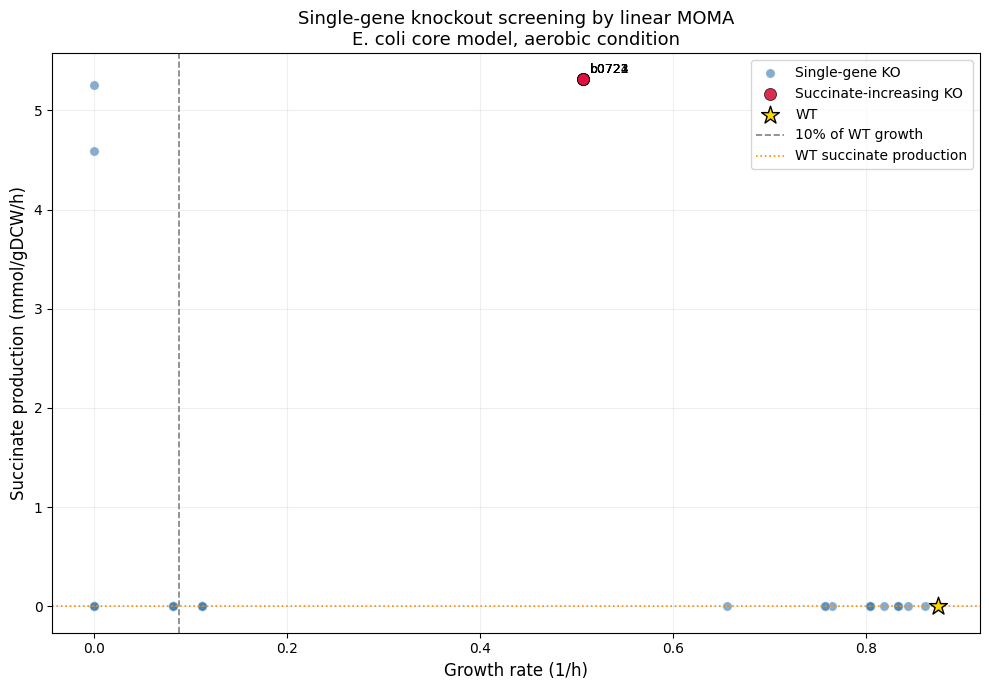


Results saved to: succinate_single_gene_moma_results.csv
Plot saved to: succinate_moma_scatter.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cobra.io import load_model
from cobra.flux_analysis import pfba
from cobra.flux_analysis.moma import moma


# ============================================================
# 1. 분석 설정
# ============================================================

MODEL_NAME = "textbook"

BIOMASS_RXN_ID = "Biomass_Ecoli_core"
SUCCINATE_EXCHANGE_ID = "EX_succ_e"

# True: 혐기 조건, False: 모델 기본 호기 조건
ANAEROBIC = False

# Linear MOMA 사용
# False로 설정하면 quadratic MOMA이며 QP solver가 필요함
LINEAR_MOMA = True

# 성장률이 WT의 몇 % 이상인 KO만 유효 후보로 볼 것인지
MIN_GROWTH_FRACTION = 0.10

RESULT_CSV = "succinate_single_gene_moma_results.csv"
PLOT_FILE = "succinate_moma_scatter.png"


# ============================================================
# 2. WT 모델 불러오기 및 배지 조건 설정
# ============================================================

model = load_model(MODEL_NAME)

if ANAEROBIC:
    # 산소 흡수 차단
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0.0

# Biomass를 목적함수로 지정
model.objective = BIOMASS_RXN_ID
model.objective_direction = "max"


# ============================================================
# 3. WT 참조 flux 계산
# ============================================================

# MOMA의 참조 flux에는 일반 FBA보다 pFBA 해가 더 안정적이다.
# 일반 FBA를 사용하려면 아래 줄을 model.optimize()으로 변경하면 된다.
wt_solution = pfba(model)

if wt_solution.status != "optimal":
    raise RuntimeError(
        f"WT 최적화 실패: status={wt_solution.status}"
    )

wt_growth = wt_solution.fluxes[BIOMASS_RXN_ID]
wt_succinate = wt_solution.fluxes[SUCCINATE_EXCHANGE_ID]

# BiGG exchange 반응에서는 양수 flux가 세포 밖으로의 분비를 의미한다.
# 수치오차로 인한 매우 작은 음수 값은 0으로 처리한다.
wt_succinate_production = max(0.0, wt_succinate)

print("WT condition:", "Anaerobic" if ANAEROBIC else "Aerobic")
print(f"WT growth: {wt_growth:.6f} 1/h")
print(
    f"WT succinate production: "
    f"{wt_succinate_production:.6f} mmol/gDCW/h"
)


# ============================================================
# 4. 전체 단일 유전자 KO + MOMA
# ============================================================

results = []

gene_ids = sorted(gene.id for gene in model.genes)

for i, gene_id in enumerate(gene_ids, start=1):

    # 매 KO마다 원래 WT 모델에서 새로운 복사본 생성
    ko_model = model.copy()

    try:
        ko_gene = ko_model.genes.get_by_id(gene_id)
        ko_gene.knock_out()

        # KO 모델의 flux가 WT 참조 flux에 가장 가깝도록 최적화
        ko_solution = moma(
            ko_model,
            solution=wt_solution,
            linear=LINEAR_MOMA
        )

        if ko_solution.status != "optimal":
            raise RuntimeError(ko_solution.status)

        # 주의:
        # ko_solution.objective_value는 성장률이 아니라 MOMA 거리이다.
        ko_growth = ko_solution.fluxes[BIOMASS_RXN_ID]
        ko_succinate_flux = ko_solution.fluxes[SUCCINATE_EXCHANGE_ID]

        # 양의 exchange flux만 생산량으로 정의
        ko_succinate_production = max(0.0, ko_succinate_flux)

        growth_fraction = (
            ko_growth / wt_growth if wt_growth > 0 else np.nan
        )

        succinate_increase = (
            ko_succinate_production - wt_succinate_production
        )

        # WT 생산량이 0이면 fold change를 정의하기 어려우므로 NaN
        if wt_succinate_production > 1e-9:
            succinate_fold_change = (
                ko_succinate_production /
                wt_succinate_production
            )
        else:
            succinate_fold_change = np.nan

        results.append({
            "gene_id": gene_id,
            "gene_name": ko_gene.name,
            "status": ko_solution.status,
            "growth": ko_growth,
            "growth_fraction_of_WT": growth_fraction,
            "succinate_production": ko_succinate_production,
            "succinate_increase_vs_WT": succinate_increase,
            "succinate_fold_change_vs_WT": succinate_fold_change,
            "moma_distance": ko_solution.objective_value,
        })

    except Exception as error:
        results.append({
            "gene_id": gene_id,
            "gene_name": model.genes.get_by_id(gene_id).name,
            "status": f"failed: {error}",
            "growth": np.nan,
            "growth_fraction_of_WT": np.nan,
            "succinate_production": np.nan,
            "succinate_increase_vs_WT": np.nan,
            "succinate_fold_change_vs_WT": np.nan,
            "moma_distance": np.nan,
        })

    if i % 10 == 0 or i == len(gene_ids):
        print(f"Processed {i}/{len(gene_ids)} genes")


# ============================================================
# 5. 결과 정리 및 succinate 증산 후보 선정
# ============================================================

results_df = pd.DataFrame(results)

# 최소 성장조건을 만족하면서 WT보다 succinate 생산이 증가한 후보
results_df["candidate"] = (
    (results_df["status"] == "optimal")
    & (
        results_df["growth_fraction_of_WT"]
        >= MIN_GROWTH_FRACTION
    )
    & (
        results_df["succinate_production"]
        > wt_succinate_production + 1e-9
    )
)

# 생산량 우선, 이후 성장률 순서로 정렬
results_df = results_df.sort_values(
    by=["candidate", "succinate_production", "growth"],
    ascending=[False, False, False]
).reset_index(drop=True)

results_df.to_csv(RESULT_CSV, index=False)

candidate_df = results_df[results_df["candidate"]].copy()

print("\nTop succinate-production KO candidates")
print(
    candidate_df[
        [
            "gene_id",
            "gene_name",
            "growth",
            "growth_fraction_of_WT",
            "succinate_production",
            "succinate_increase_vs_WT",
        ]
    ].head(20).to_string(index=False)
)


# ============================================================
# 6. Growth–succinate 2D scatter plot
# ============================================================

plot_df = results_df[
    (results_df["status"] == "optimal")
    & results_df["growth"].notna()
    & results_df["succinate_production"].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 7))

# 일반 KO
non_candidate_df = plot_df[~plot_df["candidate"]]

ax.scatter(
    non_candidate_df["growth"],
    non_candidate_df["succinate_production"],
    s=45,
    color="steelblue",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4,
    label="Single-gene KO",
)

# Succinate 증산 후보
ax.scatter(
    candidate_df["growth"],
    candidate_df["succinate_production"],
    s=75,
    color="crimson",
    alpha=0.90,
    edgecolor="black",
    linewidth=0.5,
    label="Succinate-increasing KO",
)

# WT 위치
ax.scatter(
    wt_growth,
    wt_succinate_production,
    s=180,
    marker="*",
    color="gold",
    edgecolor="black",
    linewidth=1.0,
    label="WT",
    zorder=5,
)

# 상위 10개 후보 gene ID 표시
top_candidates = candidate_df.head(10)

for _, row in top_candidates.iterrows():
    ax.annotate(
        row["gene_id"],
        xy=(row["growth"], row["succinate_production"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

# 최소 성장률 기준선
minimum_growth = wt_growth * MIN_GROWTH_FRACTION

ax.axvline(
    minimum_growth,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"{MIN_GROWTH_FRACTION:.0%} of WT growth",
)

# WT succinate 생산 기준선
ax.axhline(
    wt_succinate_production,
    color="darkorange",
    linestyle=":",
    linewidth=1.2,
    label="WT succinate production",
)

condition_label = "anaerobic" if ANAEROBIC else "aerobic"

ax.set_xlabel("Growth rate (1/h)", fontsize=12)
ax.set_ylabel(
    "Succinate production (mmol/gDCW/h)",
    fontsize=12
)
ax.set_title(
    f"Single-gene knockout screening by linear MOMA\n"
    f"E. coli core model, {condition_label} condition",
    fontsize=13,
)

ax.grid(alpha=0.20)
ax.legend(frameon=True)
fig.tight_layout()

fig.savefig(PLOT_FILE, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nResults saved to: {RESULT_CSV}")
print(f"Plot saved to: {PLOT_FILE}")